# Notebook 01 — Data Cleaning

**Goal:** Clean and normalize the structured datasets.

**Input:**
- `platform/data/admissions_linked.csv` — 55,500 Kaggle admission records
- `platform/data/patients_master.csv` — 1,163 Synthea patients

**Tasks:**
- Fix inconsistent formatting (names, dates, capitalization)
- Standardize data types
- Handle missing values
- Detect and flag demographic conflicts between datasets
- Deduplication check

**Output:** `platform/outputs/cleaned_records.csv`

## 1. Imports & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

DATA_DIR   = "../data/"
OUTPUT_DIR = "../outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Paths OK")

Paths OK


## 2. Load Data

In [2]:
admissions = pd.read_csv(os.path.join(DATA_DIR, "admissions_linked.csv"))
patients   = pd.read_csv(os.path.join(DATA_DIR, "patients_master.csv"))

print(f"Admissions : {admissions.shape}")
print(f"Patients   : {patients.shape}")
print()
print("Admissions columns:")
print(admissions.columns.tolist())
print()
admissions.head(3)

Admissions : (55500, 17)
Patients   : (1163, 21)

Admissions columns:
['patient_id', 'match_type', 'Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']



,patient_id,match_type,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,1d751b54-8ff3-4fe6-91df-751a230c94d7,gender_age_match,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,90a958eb-68a4-aa61-85e0-e9f20b083d94,gender_age_match,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,07fc8824-40ff-4c97-898d-f906bc6f2fd3,gender_age_match,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


## 3. Initial Data Quality Report

In [3]:
print("=== Initial Data Quality Report ===")
print()
print("── Missing Values ──")
print(admissions.isnull().sum())
print()
print("── Data Types ──")
print(admissions.dtypes)
print()
print("── Duplicate Rows ──")
print(f"Exact duplicates: {admissions.duplicated().sum()}")
print()
print("── Numerical Stats ──")
print(admissions[["Age", "Billing Amount", "Room Number"]].describe())

=== Initial Data Quality Report ===

── Missing Values ──
patient_id            0
match_type            0
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

── Data Types ──
patient_id                str
match_type                str
Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results           

## 4. Fix Name Formatting

In [4]:
print("Sample names BEFORE cleaning:")
print(admissions["Name"].head(10).tolist())

# Normalize names: title case, strip extra spaces
admissions["Name"] = admissions["Name"].str.strip().str.title()

print()
print("Sample names AFTER cleaning:")
print(admissions["Name"].head(10).tolist())

Sample names BEFORE cleaning:
['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll', 'EMILY JOHNSOn', 'edwArD EDWaRDs', 'CHrisTInA MARtinez', 'JASmINe aGuIlaR', 'ChRISTopher BerG']

Sample names AFTER cleaning:
['Bobby Jackson', 'Leslie Terry', 'Danny Smith', 'Andrew Watts', 'Adrienne Bell', 'Emily Johnson', 'Edward Edwards', 'Christina Martinez', 'Jasmine Aguilar', 'Christopher Berg']


## 5. Standardize Date Columns

In [5]:
# Convert date columns to datetime
admissions["Date of Admission"] = pd.to_datetime(admissions["Date of Admission"])
admissions["Discharge Date"]    = pd.to_datetime(admissions["Discharge Date"])

# Compute length of stay in days
admissions["length_of_stay"] = (
    admissions["Discharge Date"] - admissions["Date of Admission"]
).dt.days

print("Length of stay stats:")
print(admissions["length_of_stay"].describe())
print()
print("Negative length of stay (invalid):",
      (admissions["length_of_stay"] < 0).sum())

Length of stay stats:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64

Negative length of stay (invalid): 0


## 6. Standardize Categorical Columns

In [6]:
# Strip and title case all categorical columns
cat_cols = [
    "Gender", "Blood Type", "Medical Condition",
    "Admission Type", "Medication", "Test Results",
    "Insurance Provider"
]

for col in cat_cols:
    admissions[col] = admissions[col].str.strip().str.title()

print("Unique values per categorical column:")
for col in cat_cols:
    print(f"  {col:<25} → {admissions[col].unique().tolist()}")

Unique values per categorical column:
  Gender                    → ['Male', 'Female']
  Blood Type                → ['B-', 'A+', 'A-', 'O+', 'Ab+', 'Ab-', 'B+', 'O-']
  Medical Condition         → ['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
  Admission Type            → ['Urgent', 'Emergency', 'Elective']
  Medication                → ['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor']
  Test Results              → ['Normal', 'Inconclusive', 'Abnormal']
  Insurance Provider        → ['Blue Cross', 'Medicare', 'Aetna', 'Unitedhealthcare', 'Cigna']


## 7. Validate Age

Age stats:
count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

Invalid age records (< 0 or > 120): 0


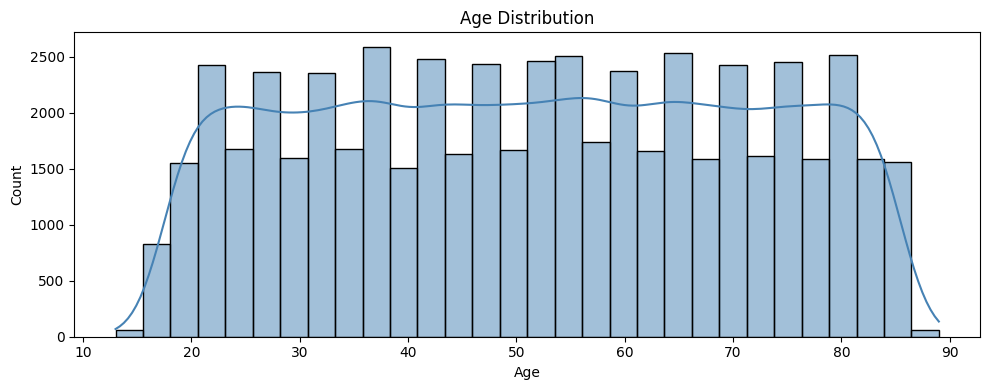

Saved → age_distribution.png


In [7]:
print("Age stats:")
print(admissions["Age"].describe())
print()

# Flag invalid ages
invalid_age = admissions[(admissions["Age"] < 0) | (admissions["Age"] > 120)]
print(f"Invalid age records (< 0 or > 120): {len(invalid_age)}")

# Visualize age distribution
plt.figure(figsize=(10, 4))
sns.histplot(admissions["Age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "age_distribution.png"))
plt.show()
print("Saved → age_distribution.png")

## 8. Validate Billing Amount

Billing Amount stats:
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64

Negative billing records: 108


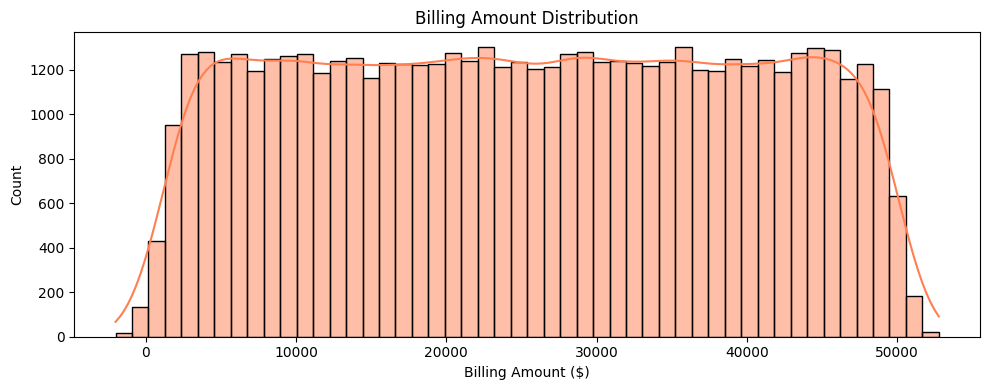

Saved → billing_distribution.png


In [8]:
print("Billing Amount stats:")
print(admissions["Billing Amount"].describe())
print()

# Flag negative billing
negative_billing = admissions[admissions["Billing Amount"] < 0]
print(f"Negative billing records: {len(negative_billing)}")

# Visualize billing distribution
plt.figure(figsize=(10, 4))
sns.histplot(admissions["Billing Amount"], bins=50, kde=True, color="coral")
plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount ($)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "billing_distribution.png"))
plt.show()
print("Saved → billing_distribution.png")

## 9. Detect Demographic Conflicts
Cross-validate patient demographics between Kaggle records and Synthea MPI.

In [9]:
# Merge admissions with MPI on patient_id
merged = admissions.merge(
    patients[["patient_id", "GENDER", "age"]],
    on="patient_id", how="left"
)

# Normalize gender for comparison
merged["kaggle_gender"] = merged["Gender"].map({"Male": "M", "Female": "F"})

# Flag gender conflicts
merged["gender_conflict"] = merged["kaggle_gender"] != merged["GENDER"]

# Flag age conflicts (difference > 10 years)
merged["age_conflict"] = abs(merged["Age"] - merged["age"]) > 10

print("=== Demographic Conflict Report ===")
print(f"Gender conflicts : {merged['gender_conflict'].sum()}")
print(f"Age conflicts    : {merged['age_conflict'].sum()}")
print()
if merged["gender_conflict"].sum() > 0:
    print("Sample gender conflicts:")
    print(merged[merged["gender_conflict"]][["patient_id", "Gender", "GENDER"]].head(5))

=== Demographic Conflict Report ===
Gender conflicts : 0
Age conflicts    : 0



## 10. Handle Missing Values

In [10]:
print("Missing values before:")
print(admissions.isnull().sum()[admissions.isnull().sum() > 0])
print()

# Fill missing categorical with 'Unknown'
cat_fill_cols = ["Doctor", "Hospital", "Insurance Provider", "Medication", "Test Results"]
for col in cat_fill_cols:
    if col in admissions.columns:
        admissions[col] = admissions[col].fillna("Unknown")

# Fill missing numerical with median
num_fill_cols = ["Billing Amount", "Room Number", "Age"]
for col in num_fill_cols:
    if col in admissions.columns:
        admissions[col] = admissions[col].fillna(admissions[col].median())

print("Missing values after:")
missing_after = admissions.isnull().sum()[admissions.isnull().sum() > 0]
print(missing_after if len(missing_after) > 0 else "None — all clean")

Missing values before:
Series([], dtype: int64)

Missing values after:
None — all clean


## 11. Add Conflict Flags to Admissions

In [11]:
# Add conflict flags from the merged dataframe back to admissions
admissions["gender_conflict"] = merged["gender_conflict"].values
admissions["age_conflict"]    = merged["age_conflict"].values
admissions["has_conflict"]    = admissions["gender_conflict"] | admissions["age_conflict"]

print("Conflict summary:")
print(f"Records with any conflict : {admissions['has_conflict'].sum()}")
print(f"Clean records             : {(~admissions['has_conflict']).sum()}")

Conflict summary:
Records with any conflict : 0
Clean records             : 55500


## 12. Final Cleaning Report

In [12]:
print("=== Final Cleaning Report ===")
print(f"Total records             : {len(admissions)}")
print(f"Duplicate rows            : {admissions.duplicated().sum()}")
print(f"Missing values remaining  : {admissions.isnull().sum().sum()}")
print(f"Invalid age records       : {((admissions['Age'] < 0) | (admissions['Age'] > 120)).sum()}")
print(f"Negative billing records  : {(admissions['Billing Amount'] < 0).sum()}")
print(f"Negative length of stay   : {(admissions['length_of_stay'] < 0).sum()}")
print(f"Gender conflicts          : {admissions['gender_conflict'].sum()}")
print(f"Age conflicts             : {admissions['age_conflict'].sum()}")
print()
print("Final columns:")
print(admissions.columns.tolist())

=== Final Cleaning Report ===
Total records             : 55500
Duplicate rows            : 8
Missing values remaining  : 0
Invalid age records       : 0
Negative billing records  : 108
Negative length of stay   : 0
Gender conflicts          : 0
Age conflicts             : 0

Final columns:
['patient_id', 'match_type', 'Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'length_of_stay', 'gender_conflict', 'age_conflict', 'has_conflict']


In [14]:
# ── Fix 1: Drop duplicate rows ─────────────────────────────────────────────
print(f"Before dedup : {len(admissions)}")
admissions = admissions.drop_duplicates().reset_index(drop=True)
print(f"After dedup  : {len(admissions)}")
print()

# ── Fix 2: Fix negative billing amounts ────────────────────────────────────
print(f"Negative billing before : {(admissions['Billing Amount'] < 0).sum()}")

# Take absolute value — billing is always positive
admissions["Billing Amount"] = admissions["Billing Amount"].abs()

print(f"Negative billing after  : {(admissions['Billing Amount'] < 0).sum()}")
print()

# Final verification
print("=== Post-Fix Verification ===")
print(f"Total records            : {len(admissions)}")
print(f"Duplicate rows           : {admissions.duplicated().sum()}")
print(f"Negative billing records : {(admissions['Billing Amount'] < 0).sum()}")

Before dedup : 55500
After dedup  : 55492

Negative billing before : 108
Negative billing after  : 0

=== Post-Fix Verification ===
Total records            : 55492
Duplicate rows           : 0
Negative billing records : 0


## 13. Save Output

In [15]:
output_path = os.path.join(OUTPUT_DIR, "cleaned_records.csv")
admissions.to_csv(output_path, index=False)

print(f"Saved → {output_path}")
print(f"Shape  : {admissions.shape}")

Saved → ../outputs/cleaned_records.csv
Shape  : (55492, 21)
